In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, classification_report
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline


### Задание 1.

Решите задачу распознавания лиц с помощью SVM с ядром. Попробуйте различные ядра: 'poly', 'rbf', 'sigmoid'.

Подберите гиперпараметры по кросс-валидации. 

SVM с каким ядром дал лучший результат?

In [2]:
#загружаем данные с лицами
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


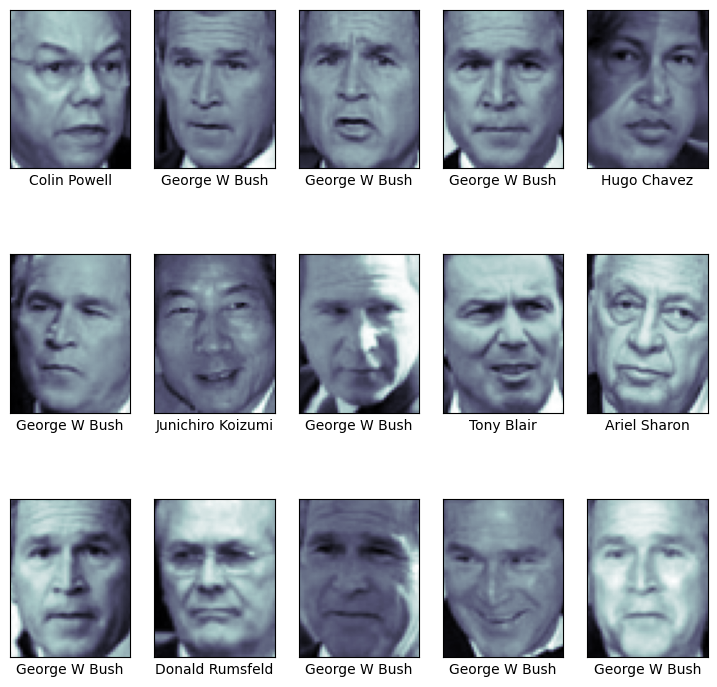

In [3]:
#визуализация данных
fig, ax = plt.subplots(3, 5, figsize=(9,9))
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

In [27]:
#уменьшаем размер данных
pca = PCA(n_components=150, svd_solver='randomized', whiten=True, random_state=42)

In [28]:
#SVM классификатор с ядром poly
svc = SVC(kernel='poly')
model = make_pipeline(pca, svc)

In [29]:
#разделение данных на трейн и тест
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,
                                                random_state=42)

In [30]:
#подбор гиперпараметров
param_grid = {'svc__C': [1, 5, 10, 50]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

CPU times: user 26 s, sys: 848 ms, total: 26.8 s
Wall time: 18.3 s
{'svc__C': 50}


In [8]:
model = grid.best_estimator_

yfit = model.predict(Xtest)

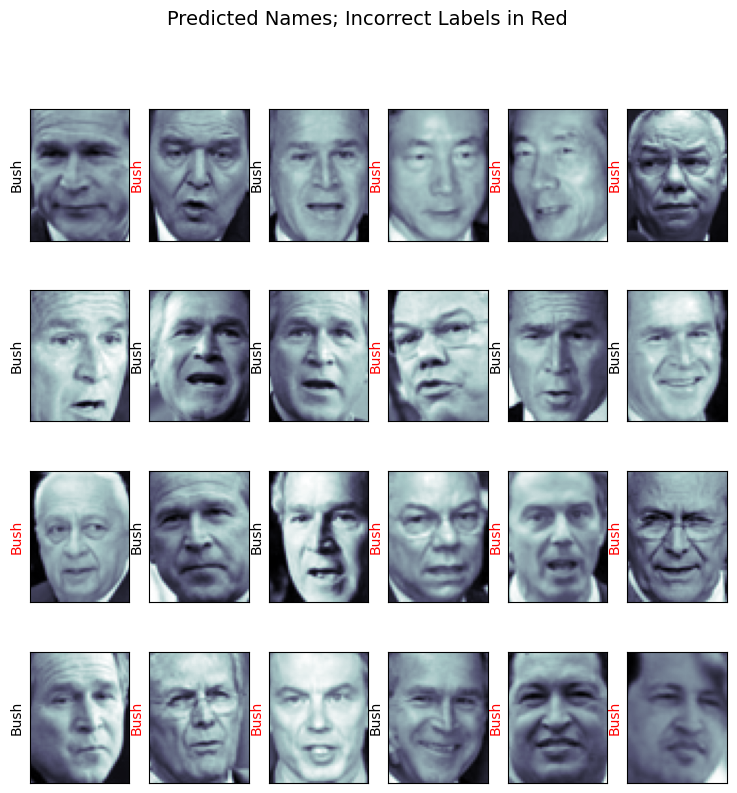

In [9]:
#визуализация предсказаний
fig, ax = plt.subplots(4, 6, figsize=(9,9))
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

In [10]:
#вывод метрик классификации
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.13      0.24        15
     Colin Powell       1.00      0.16      0.28        68
  Donald Rumsfeld       0.00      0.00      0.00        31
    George W Bush       0.40      0.99      0.57       126
Gerhard Schroeder       0.50      0.04      0.08        23
      Hugo Chavez       1.00      0.05      0.10        20
Junichiro Koizumi       1.00      0.33      0.50        12
       Tony Blair       1.00      0.07      0.13        42

         accuracy                           0.44       337
        macro avg       0.74      0.22      0.24       337
     weighted avg       0.65      0.44      0.33       337



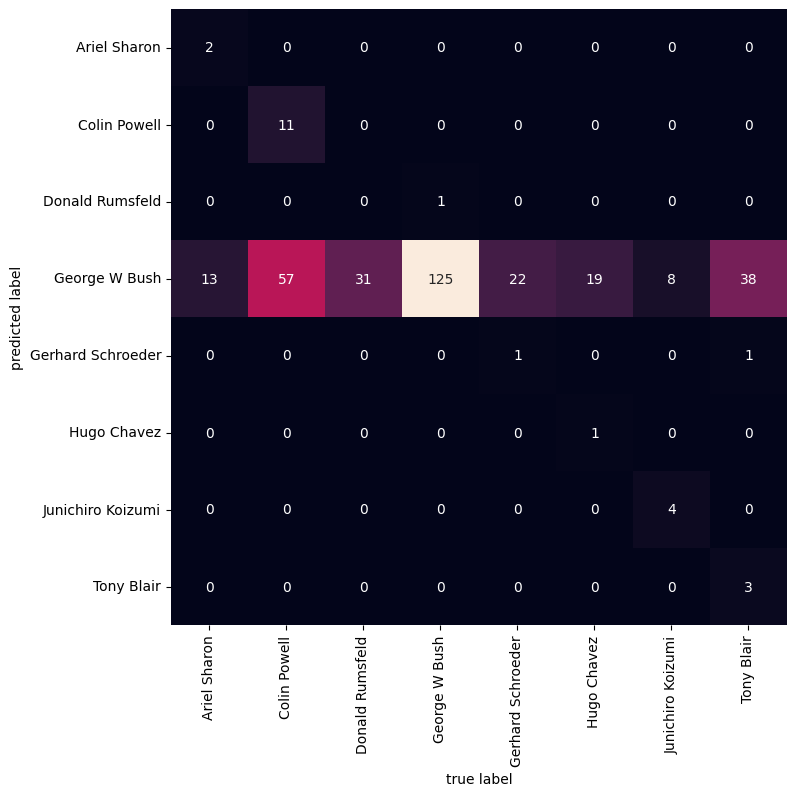

In [11]:
#вывод матрицы ощибок классификатора
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8,8))
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(yfit,ytest)

0.4362017804154303

In [13]:
#SVM классификатор с ядром rbf
svc = SVC(kernel='rbf')
pca = PCA(n_components=150, svd_solver='randomized', whiten=True, random_state=42)
model = make_pipeline(pca, svc)

from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,
                                                random_state=42)

param_grid = {'svc__C': [1, 5, 10, 50]}
grid = GridSearchCV(model, param_grid)
%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

model = grid.best_estimator_
yfit = model.predict(Xtest)

CPU times: user 24.7 s, sys: 1.42 s, total: 26.2 s
Wall time: 17.3 s
{'svc__C': 5}


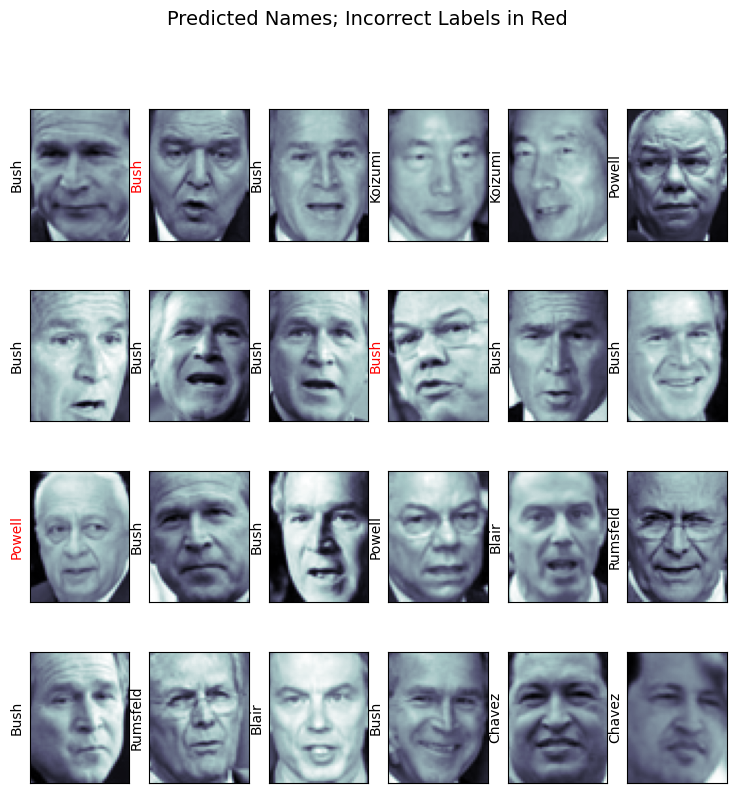

In [14]:
fig, ax = plt.subplots(4, 6, figsize=(9,9))
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

In [15]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.67      0.80        15
     Colin Powell       0.88      0.90      0.89        68
  Donald Rumsfeld       0.95      0.58      0.72        31
    George W Bush       0.74      0.97      0.84       126
Gerhard Schroeder       0.93      0.61      0.74        23
      Hugo Chavez       1.00      0.65      0.79        20
Junichiro Koizumi       1.00      0.83      0.91        12
       Tony Blair       0.92      0.79      0.85        42

         accuracy                           0.83       337
        macro avg       0.93      0.75      0.82       337
     weighted avg       0.86      0.83      0.83       337



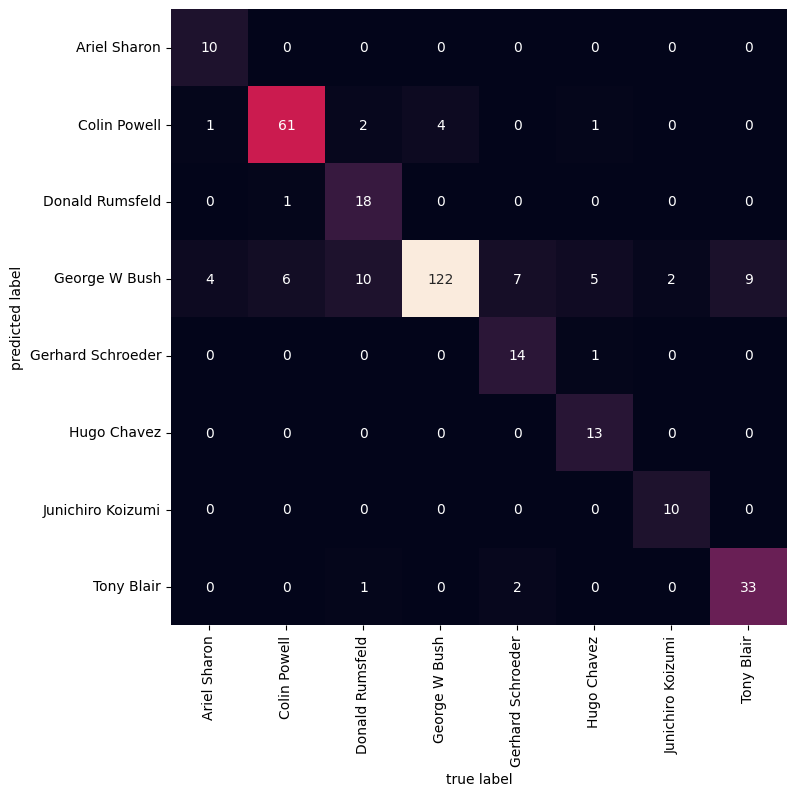

In [16]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8,8))
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(yfit,ytest)

0.8338278931750742

In [18]:
#SVM классификатор с ядром sigmoid
svc = SVC(kernel='sigmoid')
pca = PCA(n_components=150, svd_solver='randomized', whiten=True, random_state=42)
model = make_pipeline(pca, svc)

from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,
                                                random_state=42)

param_grid = {'svc__C': [1, 5, 10, 50]}
grid = GridSearchCV(model, param_grid)
%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

model = grid.best_estimator_
yfit = model.predict(Xtest)

CPU times: user 21 s, sys: 1.24 s, total: 22.2 s
Wall time: 11 s
{'svc__C': 1}


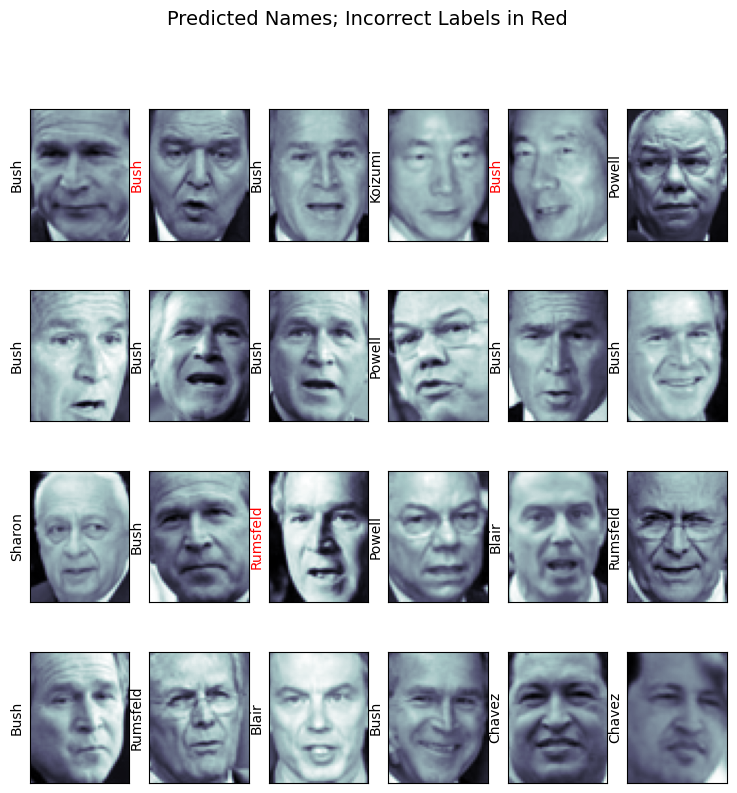

In [19]:
fig, ax = plt.subplots(4, 6, figsize=(9,9))
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

In [20]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.73      0.73      0.73        15
     Colin Powell       0.84      0.85      0.85        68
  Donald Rumsfeld       0.79      0.71      0.75        31
    George W Bush       0.82      0.89      0.85       126
Gerhard Schroeder       0.70      0.70      0.70        23
      Hugo Chavez       1.00      0.65      0.79        20
Junichiro Koizumi       1.00      0.92      0.96        12
       Tony Blair       0.80      0.79      0.80        42

         accuracy                           0.82       337
        macro avg       0.83      0.78      0.80       337
     weighted avg       0.82      0.82      0.82       337



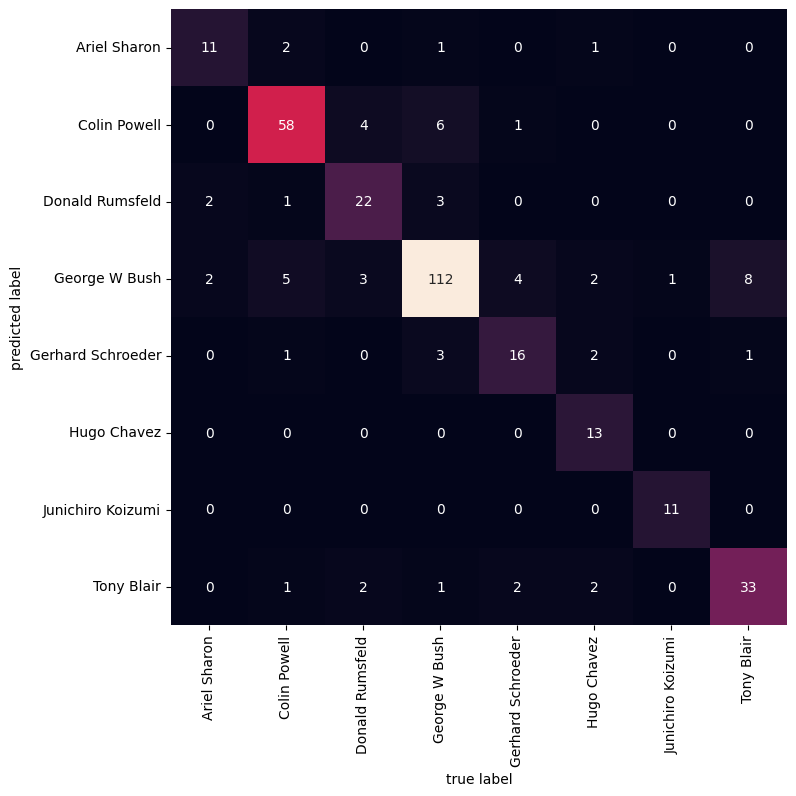

In [21]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8,8))
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(yfit,ytest)

0.8189910979228486

Лучший результат у ядра rbf - 0.834

У ядра sigmoid чуть хуже rbf - 0.819

Худший результат у ядра poly - 0.436

### Задание 2.

Решите задачу распознавания лиц с помощью логистической регрессии (она также поддерживает опцию class_weight='balanced'):

1) Объявите модель, состоящую из pipeline(pca,logistic regression)

2) Подберите по сетке параметр C логистической регрессии (с помощью GridSearch)

3) Обучите модель на тренировочных данных и выведите наилучшие параметры модели

Какое качество показала эта модель?

In [46]:
from sklearn.linear_model import LogisticRegression

#объявляю модель
lr = LogisticRegression(class_weight='balanced')
model = make_pipeline(pca, lr)

#подбор параметра С с помощью GridSearch
param_grid = {'logisticregression__C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(model, param_grid)
%time grid.fit(Xtrain, ytrain)
print('Лучший параметр С: ',grid.best_params_)

CPU times: user 20.1 s, sys: 1.28 s, total: 21.4 s
Wall time: 8.99 s
Лучший параметр С:  {'logisticregression__C': 0.1}


In [47]:
model = grid.best_estimator_
yfit = model.predict(Xtest)

In [48]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.71      0.80      0.75        15
     Colin Powell       0.85      0.88      0.86        68
  Donald Rumsfeld       0.75      0.77      0.76        31
    George W Bush       0.96      0.80      0.87       126
Gerhard Schroeder       0.65      0.74      0.69        23
      Hugo Chavez       0.82      0.70      0.76        20
Junichiro Koizumi       0.75      1.00      0.86        12
       Tony Blair       0.75      0.95      0.84        42

         accuracy                           0.83       337
        macro avg       0.78      0.83      0.80       337
     weighted avg       0.84      0.83      0.83       337



Text(72.7222222222222, 0.5, 'predicted label')

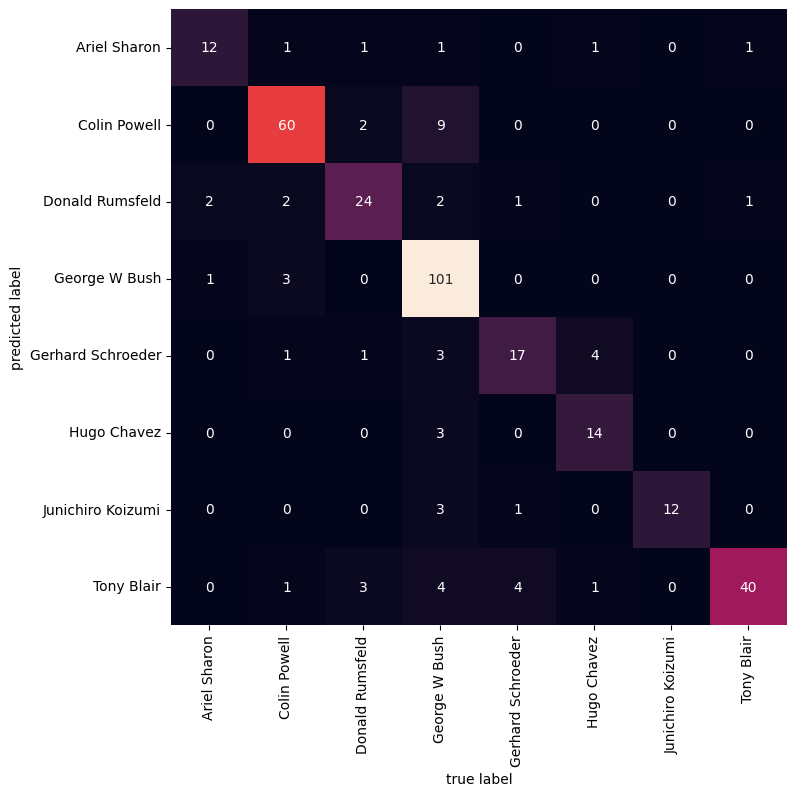

In [49]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8,8))
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')

In [50]:
from sklearn.metrics import accuracy_score
accuracy_score(yfit, ytest)

0.8308605341246291

Показатели модели с логистической регрессией (0.831) лучше, чем SVM с ядром sigmoid (0.819) и SWM с ядром poly (0.436), но хуже чем у SVM с ядром rbf (0.834), хотя разница небольшая